In [1]:
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, LassoCV
from statsmodels.stats.anova import anova_lm

In [2]:
# Load dataset
df = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

print("Original shape:", df.shape)

Original shape: (54, 263)


In [3]:
total_nulls = df.isnull().sum().sum()

print("Total missing values in dataset:", total_nulls)

Total missing values in dataset: 1


In [4]:
null_per_column = df.isnull().sum()

print(null_per_column)

District                         0
ROE                              0
student_disabilities_percent     1
student_low_income_percent       0
days_entered.x                   0
                                ..
Science_Proficiency              0
Science_Proficiency_LowIncome    0
Science_Proficiency_CWD          0
missing_frac                     0
missing_count                    0
Length: 263, dtype: int64


In [5]:
# Check which row has missing value
df[df["student_disabilities_percent"].isnull()]

,District,ROE,student_disabilities_percent,student_low_income_percent,days_entered.x,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),...,ELA_Proficiency_LowIncome,ELA_Proficiency_CWD,Math_Proficiency,Math_Proficiency_LowIncome,Math_Proficiency_CWD,Science_Proficiency,Science_Proficiency_LowIncome,Science_Proficiency_CWD,missing_frac,missing_count
27,LOSTANT CUSD 425,35.0,NaN,26.8,21.0,67.000048,5.0,5.0,2.93481,3.043476,...,60.558345,44.231892,30.8,27.499899,27.739182,42.316915,40.73494,51.344596,0.7,7.0


In [6]:
median_value = df["student_disabilities_percent"].median()

df["student_disabilities_percent"] = df["student_disabilities_percent"].fillna(median_value)

print("Missing after imputation:", df["student_disabilities_percent"].isnull().sum())

Missing after imputation: 0


In [7]:
cols_to_drop = [
    # Identifiers
    "ROE",
    
    # Tracking / merge artifacts
    "days_entered.x",
    "days_entered.y",
    "Day of Menu",
    
    # Metadata
    "Data Collected in NCC Database Version",
    "Data Collected in Software Version",
    "Data Generated in NCC Database Version",
    "Data Generated in Software Version",
    
    # Missing diagnostics 
    "missing_frac",
    "missing_count",

    "ELA_Proficiency_LowIncome",
    "ELA_Proficiency_CWD",
    "Math_Proficiency_LowIncome",
    "Math_Proficiency_CWD",
    "Science_Proficiency_LowIncome",
    "Science_Proficiency_CWD"
]

In [8]:
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("After removing non-analytical columns:", df_clean.shape)

After removing non-analytical columns: (54, 247)


In [9]:
removed = set(df.columns) - set(df_clean.columns)
print("Removed columns:")
print(removed)

Removed columns:
{'Science_Proficiency_LowIncome', 'Data Generated in Software Version', 'ELA_Proficiency_LowIncome', 'missing_count', 'ELA_Proficiency_CWD', 'missing_frac', 'ROE', 'Data Collected in NCC Database Version', 'Data Generated in NCC Database Version', 'Math_Proficiency_LowIncome', 'Data Collected in Software Version', 'Math_Proficiency_CWD', 'Science_Proficiency_CWD', 'Day of Menu', 'days_entered.y', 'days_entered.x'}


In [10]:
# Identify columns ending with .x or .y
x_cols = [col for col in df_clean.columns if col.endswith(".x")]
y_cols = [col for col in df_clean.columns if col.endswith(".y")]

print("Columns ending with .x:", x_cols)
print("Columns ending with .y:", y_cols)

Columns ending with .x: ['% Calories from SFA.x', 'Total Saturated Fatty Acids (SFA) (g).x', 'Energy (kcal).x']
Columns ending with .y: ['Energy (kcal).y', 'Total Saturated Fatty Acids (SFA) (g).y', '% Calories from SFA.y']


In [11]:
# Remove .x / .y Duplicate Columns (Keep One)
cols_to_drop = []

for col in x_cols:
    base_name = col[:-2]  # remove ".x"
    y_version = base_name + ".y"
    
    if y_version in df_clean.columns:
        # If both exist, drop the .y version
        cols_to_drop.append(y_version)

df_clean = df_clean.drop(columns=cols_to_drop)

print("Removed duplicate .y columns")
print("New shape:", df_clean.shape)

Removed duplicate .y columns
New shape: (54, 244)


In [12]:
# Remove EXACT Duplicate Columns (Same Values)
import numpy as np

duplicate_columns = []

for i in range(len(df_clean.columns)):
    for j in range(i + 1, len(df_clean.columns)):
        col1 = df_clean.columns[i]
        col2 = df_clean.columns[j]
        
        if df_clean[col1].equals(df_clean[col2]):
            duplicate_columns.append(col2)

# Remove duplicates
df_clean = df_clean.drop(columns=list(set(duplicate_columns)))

print("Exact duplicate columns removed:", duplicate_columns)
print("Shape after removing exact duplicates:", df_clean.shape)

Exact duplicate columns removed: ['Whole Grains (ounce equivalents)', 'Refined Grains (ounce equivalents)', 'Sucrose Polyester (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutrient 14 (mg)', 'User Nutrient 15 (mg)', 'User Nutrient 16 (mg)', 'User Nutrient 17 (mg)', 'User Nutrient 18 (mg)', 'User Nutrient 19 (mg)', 'User Nutrient 20 (mg)', 'Sucralose (mg)', 'Isomalt (g)', 'Lactitol (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutri

In [13]:
# Remove Duplicate Energy Columns
energy_cols = [col for col in df_clean.columns if "Energy" in col]
print("Energy-related columns:", energy_cols)

Energy-related columns: ['Energy (kcal).x', 'Energy (kj)']


In [14]:
if "Energy (kj)" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Energy (kj)"])

In [15]:
print("Final shape after duplicate removal:", df_clean.shape)

Final shape after duplicate removal: (54, 217)


In [16]:
# Keep numeric columns only
df_numeric = df_clean.select_dtypes(include=[np.number])

print("Numeric shape:", df_numeric.shape)

Numeric shape: (54, 216)


In [17]:
variances = df_numeric.var()

# Look at smallest variances
variances.sort_values().head(10)

Saccharin (mg)                                     0.000000e+00
Maltitol (g)                                       4.053150e-08
Erythritol (g)                                     3.200367e-07
PUFA 20:5 n-3 (eicosapentaenoic acid [EPA]) (g)    1.626067e-05
Xylitol (g)                                        4.483152e-05
CLA trans-10, cis-12 (g)                           4.506519e-05
PUFA 22:5 n-3 (docosapentaenoic acid [DPA]) (g)    4.847515e-05
% Calories from Alcohol                            7.560004e-05
PUFA 18:4 (parinaric acid) (g)                     7.758662e-05
PUFA 22:6 n-3 (docosahexaenoic acid [DHA]) (g)     8.634814e-05
dtype: float64

In [18]:
from sklearn.feature_selection import VarianceThreshold

# Set small threshold
selector = VarianceThreshold(threshold=0.01)

X_reduced = selector.fit_transform(df_numeric)

# Get kept columns
kept_columns = df_numeric.columns[selector.get_support()]

# Create new cleaned dataframe
df_variance_clean = df_numeric[kept_columns]

print("Before variance filtering:", df_numeric.shape)
print("After variance filtering:", df_variance_clean.shape)

Before variance filtering: (54, 216)
After variance filtering: (54, 191)


In [19]:
score_cols = [
    "ELA_Proficiency",
    "Math_Proficiency",
    "Science_Proficiency"
]

df_variance_clean["avg_score"] = df_variance_clean[score_cols].mean(axis=1)

predictors_to_exclude = score_cols + ["avg_score"]

/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_24884/329509845.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_variance_clean["avg_score"] = df_variance_clean[score_cols].mean(axis=1)


In [20]:
# Define X and y

predictors_to_exclude = score_cols + ["avg_score"]

X = df_variance_clean.drop(columns=[col for col in predictors_to_exclude if col in df_variance_clean.columns])
y = df_variance_clean["avg_score"]

# drop NA just in case
model_data = pd.concat([X, y], axis=1).dropna()
X = model_data[X.columns]
y = model_data["avg_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (54, 188)
y shape: (54,)


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print("Best lambda (alpha):", best_alpha)

Best lambda (alpha): 1.1416678340293662


In [23]:
lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
lasso_model.fit(X_scaled, y)

Lasso(alpha=np.float64(1.1416678340293662), max_iter=10000)

In [24]:
lasso_coef_table = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_model.coef_
}).sort_values('Lasso_Coefficient', key=np.abs, ascending=False)

lasso_coef_table.head(30)

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-11.632067
28,% Calories from SFA.x,-2.466288
29,Total Fruit Servings in cup equivalents,-2.141867
142,Beta-Cryptoxanthin (provitamin A carotenoid) (...,-2.078767
12,HEI 2015 Refined Grains (0-10),-1.590342
126,3-Methylhistidine (mg),-1.321674
20,Whole Grain Servings in ounce equivalents per ...,-1.311629
141,Alpha-Carotene (provitamin A carotenoid) (mcg),-1.283348
0,student_disabilities_percent,-1.142982
122,Aspartame (mg),-0.429621


In [25]:
lasso_selected = lasso_coef_table[lasso_coef_table['Lasso_Coefficient'] != 0].copy()
lasso_selected

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-11.632067
28,% Calories from SFA.x,-2.466288
29,Total Fruit Servings in cup equivalents,-2.141867
142,Beta-Cryptoxanthin (provitamin A carotenoid) (...,-2.078767
12,HEI 2015 Refined Grains (0-10),-1.590342
126,3-Methylhistidine (mg),-1.321674
20,Whole Grain Servings in ounce equivalents per ...,-1.311629
141,Alpha-Carotene (provitamin A carotenoid) (mcg),-1.283348
0,student_disabilities_percent,-1.142982
122,Aspartame (mg),-0.429621


In [26]:
selected_predictors = lasso_selected['Predictor'].tolist()

print("Selected predictors:")
print(selected_predictors)
print("Number selected:", len(selected_predictors))

Selected predictors:
['student_low_income_percent', '% Calories from SFA.x', 'Total Fruit Servings in cup equivalents', 'Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)', 'HEI 2015 Refined Grains (0-10)', '3-Methylhistidine (mg)', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Alpha-Carotene (provitamin A carotenoid) (mcg)', 'student_disabilities_percent', 'Aspartame (mg)', 'HEI 2015 Greens and Beans (0-5)', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Maltose (g)', 'Lutein + Zeaxanthin (mcg)']
Number selected: 14


In [27]:
X_selected = model_data[selected_predictors]
X_selected_const = sm.add_constant(X_selected)

ols_model = sm.OLS(y, X_selected_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              avg_score   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     17.30
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.61e-12
Time:                        20:54:44   Log-Likelihood:                -180.89
No. Observations:                  54   AIC:                             391.8
Df Residuals:                      39   BIC:                             421.6
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [28]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_selected_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_selected_const.values, i)
    for i in range(X_selected_const.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                                             Variable         VIF
0                                               const  144.251244
14                          Lutein + Zeaxanthin (mcg)    3.531230
11                    HEI 2015 Greens and Beans (0-5)    2.980820
3             Total Fruit Servings in cup equivalents    2.639227
5                      HEI 2015 Refined Grains (0-10)    2.570891
4   Beta-Cryptoxanthin (provitamin A carotenoid) (...    2.564977
13                                        Maltose (g)    2.346522
12  Seafood and Plant Protein Servings in ounce eq...    2.068960
2                               % Calories from SFA.x    1.898173
8      Alpha-Carotene (provitamin A carotenoid) (mcg)    1.823806
6                              3-Methylhistidine (mg)    1.788056
1                          student_low_income_percent    1.527058
9                        student_disabilities_percent    1.249942
10                                     Aspartame (mg)    1.227738
7   Whole 

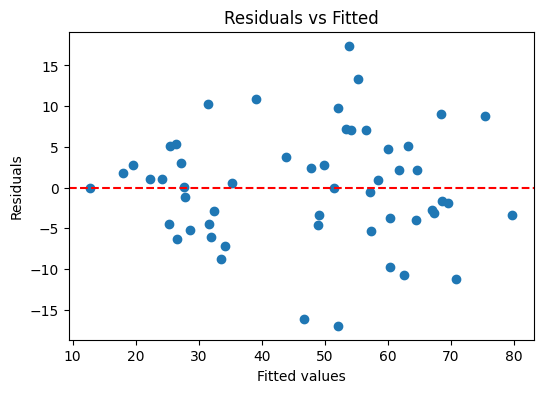

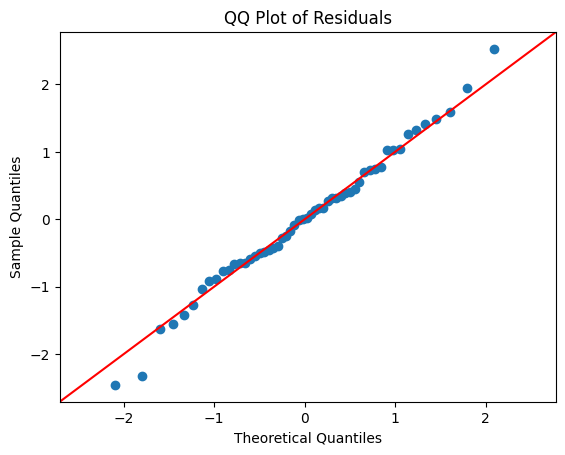

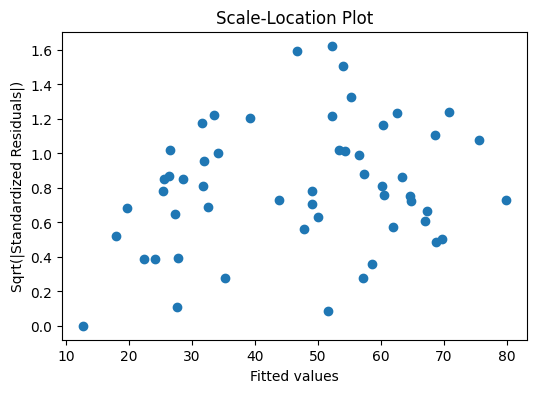

In [29]:
# Diagnostic plots

fitted_vals = ols_model.fittedvalues
residuals = ols_model.resid
standardized_residuals = ols_model.get_influence().resid_studentized_internal

plt.figure(figsize=(6, 4))
plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()


plt.figure(figsize=(6, 4))
plt.scatter(fitted_vals, np.sqrt(np.abs(standardized_residuals)))
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

In [30]:
influence = OLSInfluence(ols_model)

cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
dffits = influence.dffits[0]
studentized_residuals = influence.resid_studentized_external

n = X_selected_const.shape[0]
p = X_selected_const.shape[1]   # includes intercept

# Common cutoffs
cooks_cutoff = 4 / n
leverage_cutoff = 2 * p / n
dffits_cutoff = 2 * np.sqrt(p / n)

print("Cook's distance cutoff:", cooks_cutoff)
print("Leverage cutoff:", leverage_cutoff)
print("DFFITS cutoff:", dffits_cutoff)

Cook's distance cutoff: 0.07407407407407407
Leverage cutoff: 0.5555555555555556
DFFITS cutoff: 1.0540925533894598


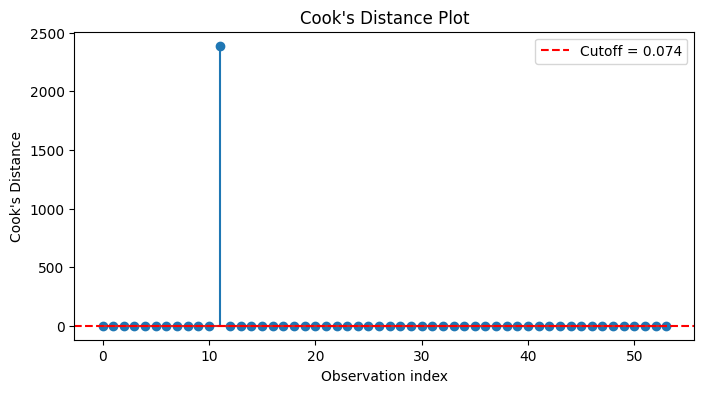

In [31]:
plt.figure(figsize=(8, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d)
plt.axhline(cooks_cutoff, color='red', linestyle='--', label=f"Cutoff = {cooks_cutoff:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot")
plt.legend()
plt.show()

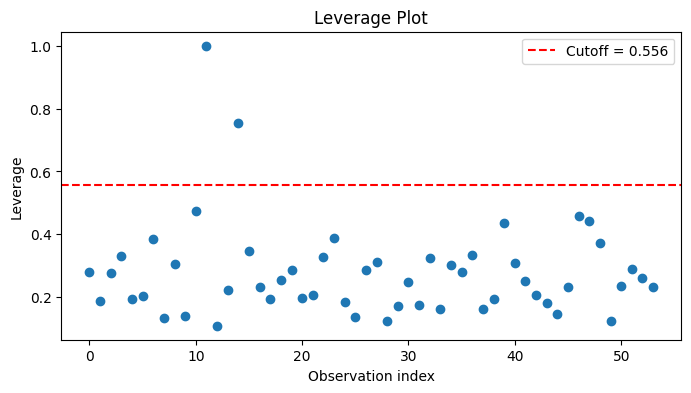

In [32]:
plt.figure(figsize=(8, 4))
plt.scatter(np.arange(len(leverage)), leverage)
plt.axhline(leverage_cutoff, color='red', linestyle='--', label=f"Cutoff = {leverage_cutoff:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Leverage")
plt.title("Leverage Plot")
plt.legend()
plt.show()

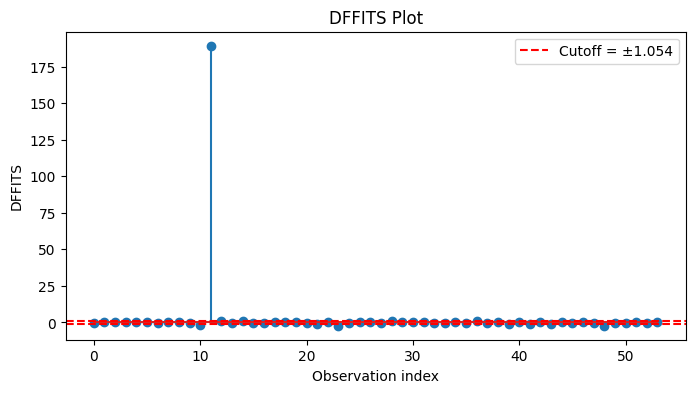

In [33]:
plt.figure(figsize=(8, 4))
plt.stem(np.arange(len(dffits)), dffits)
plt.axhline(dffits_cutoff, color='red', linestyle='--')
plt.axhline(-dffits_cutoff, color='red', linestyle='--', label=f"Cutoff = ±{dffits_cutoff:.3f}")
plt.xlabel("Observation index")
plt.ylabel("DFFITS")
plt.title("DFFITS Plot")
plt.legend()
plt.show()

In [34]:
influence_df = pd.DataFrame({
    "Index": np.arange(n),
    "Fitted": fitted_vals,
    "Residual": residuals,
    "Studentized_Residual": studentized_residuals,
    "Cooks_D": cooks_d,
    "Leverage": leverage,
    "DFFITS": dffits
})

influence_df["Flag_Cooks"] = influence_df["Cooks_D"] > cooks_cutoff
influence_df["Flag_Leverage"] = influence_df["Leverage"] > leverage_cutoff
influence_df["Flag_DFFITS"] = np.abs(influence_df["DFFITS"]) > dffits_cutoff

influence_df["n_flags"] = (
    influence_df["Flag_Cooks"].astype(int) +
    influence_df["Flag_Leverage"].astype(int) +
    influence_df["Flag_DFFITS"].astype(int)
)

flagged_points = influence_df[influence_df["n_flags"] > 0].sort_values("n_flags", ascending=False)

print(flagged_points)

    Index     Fitted      Residual  Studentized_Residual      Cooks_D  \
11     11  12.695622  3.410605e-13              0.000003  2389.075284   
10     10  33.568151 -8.780651e+00             -1.515022     0.132839   
23     23  46.713870 -1.608054e+01             -2.734813     0.270627   
48     48  52.187351 -1.695402e+01             -2.873099     0.275681   
14     14  64.701068  2.125598e+00              0.523440     0.057105   
36     36  52.160394  9.772939e+00              1.497973     0.072331   

    Leverage      DFFITS  Flag_Cooks  Flag_Leverage  Flag_DFFITS  n_flags  
11  1.000000  189.304330        True           True         True        3  
10  0.472838   -1.434839        True          False         True        2  
23  0.387604   -2.175731        True          False         True        2  
48  0.372702   -2.214596        True          False         True        2  
14  0.754186    0.916861       False           True        False        1  
36  0.332860    1.058099       F

In [35]:
flagged_points.sort_values("Cooks_D", ascending=False).head()

,Index,Fitted,Residual,Studentized_Residual,Cooks_D,Leverage,DFFITS,Flag_Cooks,Flag_Leverage,Flag_DFFITS,n_flags
11,11,12.695622,3.410605e-13,0.000003,2389.075284,1.000000,189.304330,True,True,True,3
48,48,52.187351,-1.695402e+01,-2.873099,0.275681,0.372702,-2.214596,True,False,True,2
23,23,46.713870,-1.608054e+01,-2.734813,0.270627,0.387604,-2.175731,True,False,True,2
10,10,33.568151,-8.780651e+00,-1.515022,0.132839,0.472838,-1.434839,True,False,True,2
36,36,52.160394,9.772939e+00,1.497973,0.072331,0.332860,1.058099,False,False,True,1


In [36]:
df_variance_clean.iloc[11]

student_disabilities_percent    19.000000
student_low_income_percent      86.900000
HEI 2015 Total Score            57.769571
HEI 2015 Total Fruits (0-5)      4.763571
HEI 2015 Whole Fruits (0-5)      4.181048
                                  ...    
Omega-6 Fatty Acids (g)         10.453095
ELA_Proficiency                 17.200000
Math_Proficiency                 8.600000
Science_Proficiency             12.286867
avg_score                       12.695622
Name: 11, Length: 192, dtype: float64

In [37]:
# Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(residuals, X_selected_const)
bp_results = pd.DataFrame({
    "Statistic": ["LM Stat", "LM p-value", "F Stat", "F p-value"],
    "Value": bp_test
})
print("\nBreusch-Pagan Test")
print(bp_results)

# Durbin-Watson test for autocorrelation
dw_stat = durbin_watson(residuals)
print("\nDurbin-Watson Statistic:", dw_stat)


Breusch-Pagan Test
    Statistic      Value
0     LM Stat  12.675778
1  LM p-value   0.552197
2      F Stat   0.854489
3   F p-value   0.609875

Durbin-Watson Statistic: 2.3403657077355837


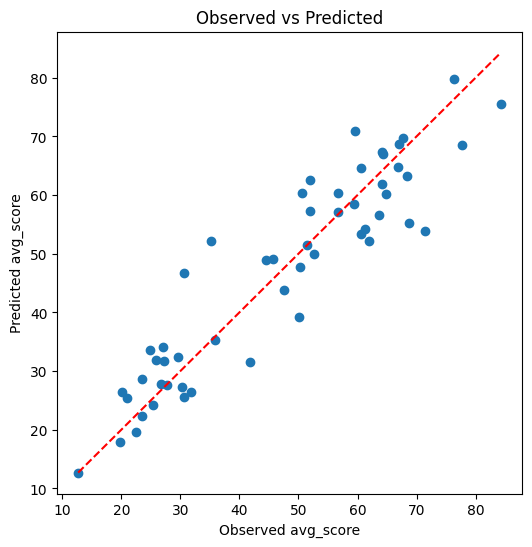

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(y, fitted_vals)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Observed avg_score")
plt.ylabel("Predicted avg_score")
plt.title("Observed vs Predicted")
plt.show()

### Model after handling highly influential points

In [39]:
model_data_clean = model_data.drop(index=11)

X_selected_clean = model_data_clean[selected_predictors]
y_clean = model_data_clean["avg_score"]

X_selected_clean = sm.add_constant(X_selected_clean)

ols_model_clean = sm.OLS(y_clean, X_selected_clean).fit()
print(ols_model_clean.summary())

                            OLS Regression Results                            
Dep. Variable:              avg_score   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     17.24
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.95e-12
Time:                        20:54:44   Log-Likelihood:                -178.04
No. Observations:                  53   AIC:                             384.1
Df Residuals:                      39   BIC:                             411.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

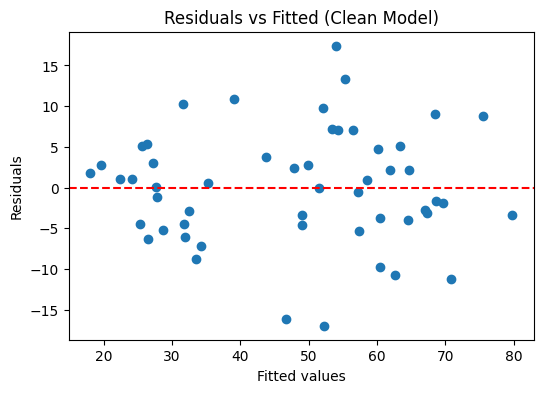

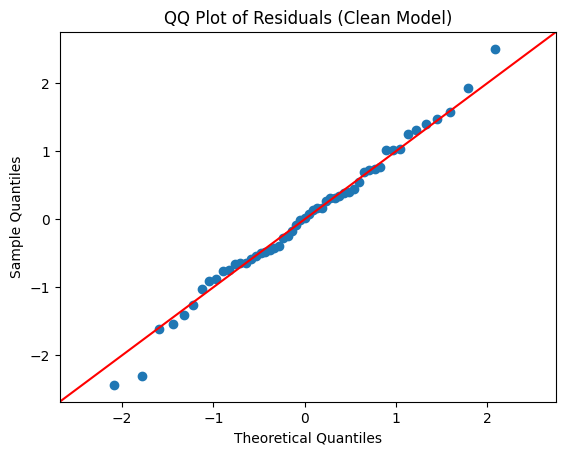

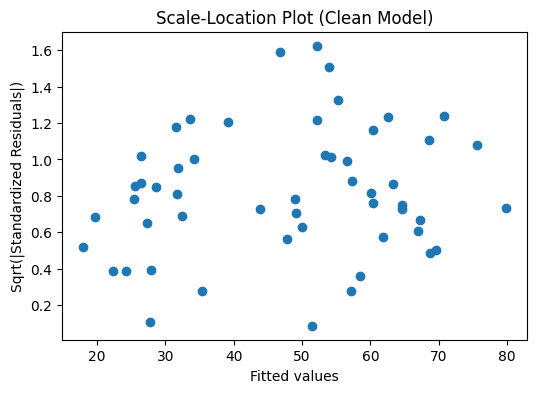

In [40]:
# Residuals and fitted values
fitted_vals_clean = ols_model_clean.fittedvalues
residuals_clean = ols_model_clean.resid

influence_clean = OLSInfluence(ols_model_clean)
std_resid_clean = influence_clean.resid_studentized_internal

# Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals_clean, residuals_clean)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Clean Model)")
plt.show()

# QQ plot
sm.qqplot(residuals_clean, line='45', fit=True)
plt.title("QQ Plot of Residuals (Clean Model)")
plt.show()

# Scale-location plot
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals_clean, np.sqrt(np.abs(std_resid_clean)))
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot (Clean Model)")
plt.show()

In [41]:
# Influence measures
cooks_d_clean = influence_clean.cooks_distance[0]
leverage_clean = influence_clean.hat_matrix_diag
dffits_clean = influence_clean.dffits[0]
studentized_residuals_clean = influence_clean.resid_studentized_external

n_clean = X_selected_clean.shape[0]
p_clean = X_selected_clean.shape[1]   # includes intercept

# Cutoffs
cooks_cutoff_clean = 4 / n_clean
leverage_cutoff_clean = 2 * p_clean / n_clean
dffits_cutoff_clean = 2 * np.sqrt(p_clean / n_clean)

print("Cook's cutoff:", cooks_cutoff_clean)
print("Leverage cutoff:", leverage_cutoff_clean)
print("DFFITS cutoff:", dffits_cutoff_clean)

Cook's cutoff: 0.07547169811320754
Leverage cutoff: 0.5660377358490566
DFFITS cutoff: 1.063990353197863


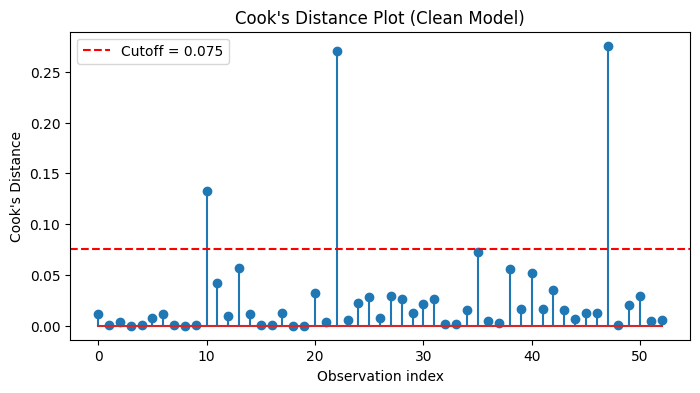

In [42]:
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(cooks_d_clean)), cooks_d_clean)
plt.axhline(cooks_cutoff_clean, color='red', linestyle='--', label=f"Cutoff = {cooks_cutoff_clean:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot (Clean Model)")
plt.legend()
plt.show()

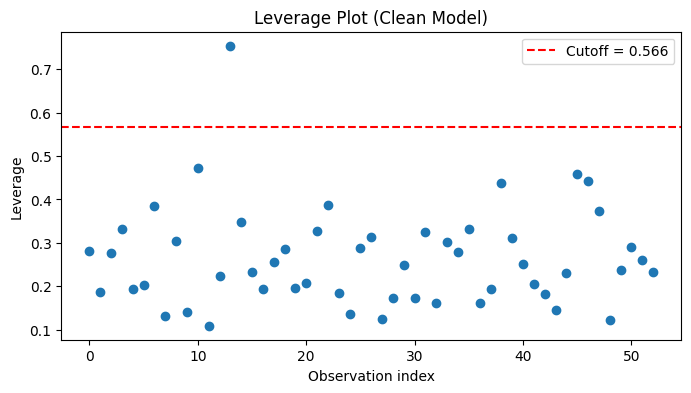

In [43]:
plt.figure(figsize=(8,4))
plt.scatter(np.arange(len(leverage_clean)), leverage_clean)
plt.axhline(leverage_cutoff_clean, color='red', linestyle='--', label=f"Cutoff = {leverage_cutoff_clean:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Leverage")
plt.title("Leverage Plot (Clean Model)")
plt.legend()
plt.show()

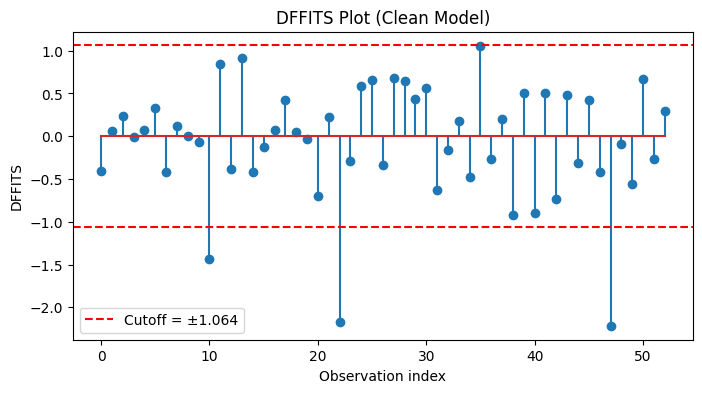

In [44]:
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(dffits_clean)), dffits_clean)
plt.axhline(dffits_cutoff_clean, color='red', linestyle='--')
plt.axhline(-dffits_cutoff_clean, color='red', linestyle='--', label=f"Cutoff = ±{dffits_cutoff_clean:.3f}")
plt.xlabel("Observation index")
plt.ylabel("DFFITS")
plt.title("DFFITS Plot (Clean Model)")
plt.legend()
plt.show()

In [45]:
diag_clean = pd.DataFrame({
    "Index": model_data_clean.index,
    "Fitted": fitted_vals_clean,
    "Residual": residuals_clean,
    "Studentized_Residual": studentized_residuals_clean,
    "Cooks_D": cooks_d_clean,
    "Leverage": leverage_clean,
    "DFFITS": dffits_clean
})

diag_clean["Flag_Cooks"] = diag_clean["Cooks_D"] > cooks_cutoff_clean
diag_clean["Flag_Leverage"] = diag_clean["Leverage"] > leverage_cutoff_clean
diag_clean["Flag_DFFITS"] = np.abs(diag_clean["DFFITS"]) > dffits_cutoff_clean

diag_clean["n_flags"] = (
    diag_clean["Flag_Cooks"].astype(int) +
    diag_clean["Flag_Leverage"].astype(int) +
    diag_clean["Flag_DFFITS"].astype(int)
)

flagged_clean = diag_clean[diag_clean["n_flags"] > 0].sort_values("n_flags", ascending=False)
print(flagged_clean)

    Index     Fitted   Residual  Studentized_Residual   Cooks_D  Leverage  \
10     10  33.568151  -8.780651             -1.515022  0.132839  0.472838   
23     23  46.713870 -16.080537             -2.734813  0.270627  0.387604   
48     48  52.187351 -16.954018             -2.873099  0.275681  0.372702   
14     14  64.701068   2.125598              0.523440  0.057105  0.754186   

      DFFITS  Flag_Cooks  Flag_Leverage  Flag_DFFITS  n_flags  
10 -1.434839        True          False         True        2  
23 -2.175731        True          False         True        2  
48 -2.214596        True          False         True        2  
14  0.916861       False           True        False        1  


After removing the extreme observation, the model is much better than before, but diagnostics still suggest:

3 moderately influential observations remain: 10, 23, 48
1 high-leverage observation remains: 14
no single point is destroying the model like before
but the model is still somewhat sensitive

In [46]:
vif_clean = pd.DataFrame()
vif_clean["Variable"] = X_selected_clean.columns
vif_clean["VIF"] = [
    variance_inflation_factor(X_selected_clean.values, i)
    for i in range(X_selected_clean.shape[1])
]

print(vif_clean.sort_values("VIF", ascending=False))

                                             Variable         VIF
0                                               const  141.579925
14                          Lutein + Zeaxanthin (mcg)    3.531130
11                    HEI 2015 Greens and Beans (0-5)    2.937275
3             Total Fruit Servings in cup equivalents    2.614761
4   Beta-Cryptoxanthin (provitamin A carotenoid) (...    2.496419
5                      HEI 2015 Refined Grains (0-10)    2.455578
13                                        Maltose (g)    2.344212
12  Seafood and Plant Protein Servings in ounce eq...    2.050483
2                               % Calories from SFA.x    1.898168
8      Alpha-Carotene (provitamin A carotenoid) (mcg)    1.819890
6                              3-Methylhistidine (mg)    1.774730
1                          student_low_income_percent    1.462053
9                        student_disabilities_percent    1.248545
7   Whole Grain Servings in ounce equivalents per ...    1.223011
10        

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


### Handling again

In [47]:
model_data_clean2 = model_data_clean.drop(index=[23, 48])

X_sens = model_data_clean2[selected_predictors]
y_sens = model_data_clean2["avg_score"]

X_sens = sm.add_constant(X_sens)

ols_model_sens = sm.OLS(y_sens, X_sens).fit()
print(ols_model_sens.summary())

                            OLS Regression Results                            
Dep. Variable:              avg_score   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     24.04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.95e-14
Time:                        20:54:44   Log-Likelihood:                -163.03
No. Observations:                  51   AIC:                             354.1
Df Residuals:                      37   BIC:                             381.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

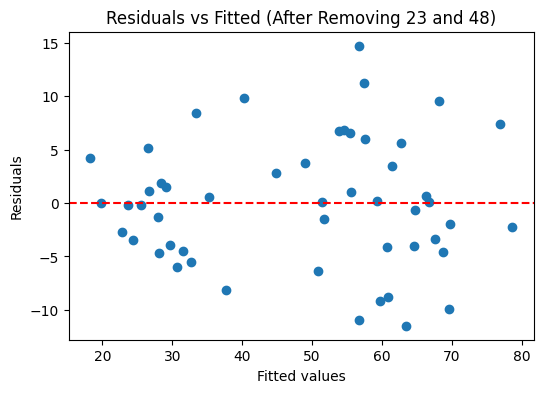

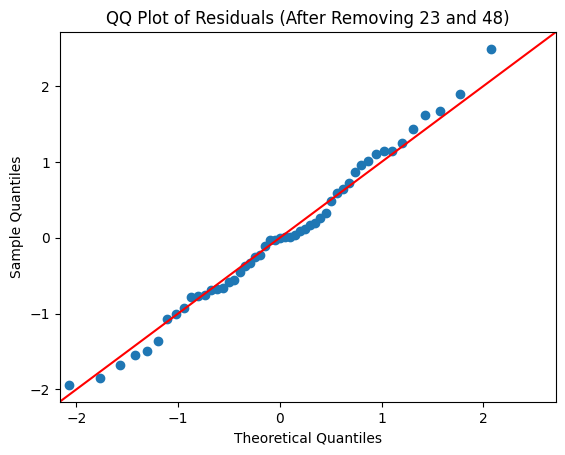

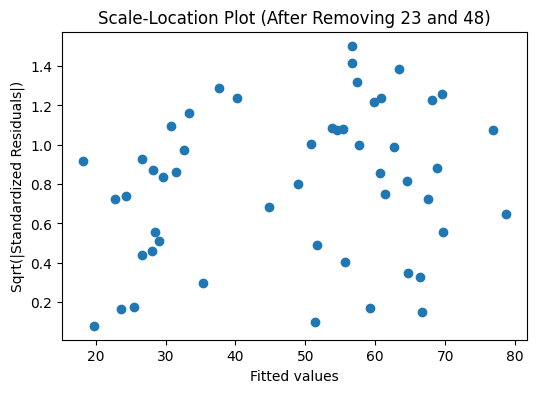

In [48]:
# Residuals and fitted values
fitted_vals_sens = ols_model_sens.fittedvalues
residuals_sens = ols_model_sens.resid

influence_sens = OLSInfluence(ols_model_sens)
std_resid_sens = influence_sens.resid_studentized_internal

# Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals_sens, residuals_sens)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (After Removing 23 and 48)")
plt.show()

# QQ plot
sm.qqplot(residuals_sens, line='45', fit=True)
plt.title("QQ Plot of Residuals (After Removing 23 and 48)")
plt.show()

# Scale-Location plot
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals_sens, np.sqrt(np.abs(std_resid_sens)))
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot (After Removing 23 and 48)")
plt.show()

In [49]:
# Influence measures
cooks_d_sens = influence_sens.cooks_distance[0]
leverage_sens = influence_sens.hat_matrix_diag
dffits_sens = influence_sens.dffits[0]
studentized_residuals_sens = influence_sens.resid_studentized_external

n_sens = X_sens.shape[0]
p_sens = X_sens.shape[1]   # includes intercept

# Cutoffs
cooks_cutoff_sens = 4 / n_sens
leverage_cutoff_sens = 2 * p_sens / n_sens
dffits_cutoff_sens = 2 * np.sqrt(p_sens / n_sens)

print("Cook's cutoff:", cooks_cutoff_sens)
print("Leverage cutoff:", leverage_cutoff_sens)
print("DFFITS cutoff:", dffits_cutoff_sens)

Cook's cutoff: 0.0784313725490196
Leverage cutoff: 0.5882352941176471
DFFITS cutoff: 1.0846522890932808


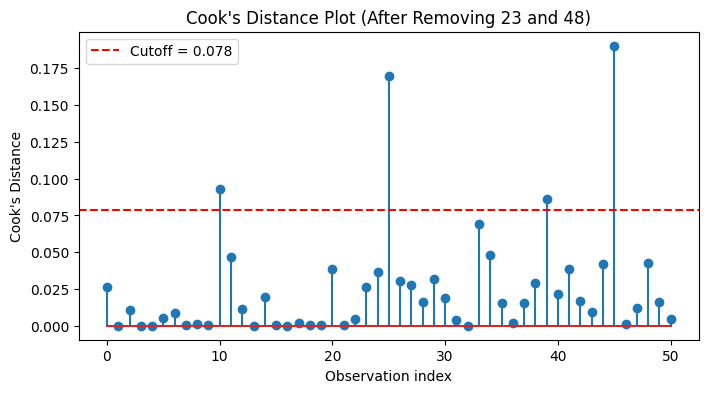

In [50]:
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(cooks_d_sens)), cooks_d_sens)
plt.axhline(cooks_cutoff_sens, color='red', linestyle='--', label=f"Cutoff = {cooks_cutoff_sens:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance Plot (After Removing 23 and 48)")
plt.legend()
plt.show()

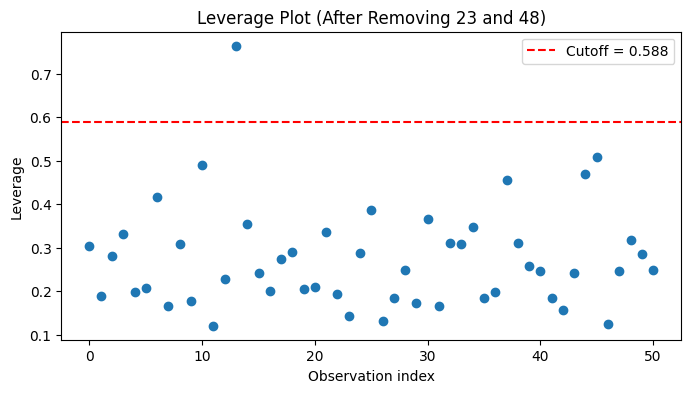

In [51]:
plt.figure(figsize=(8,4))
plt.scatter(np.arange(len(leverage_sens)), leverage_sens)
plt.axhline(leverage_cutoff_sens, color='red', linestyle='--', label=f"Cutoff = {leverage_cutoff_sens:.3f}")
plt.xlabel("Observation index")
plt.ylabel("Leverage")
plt.title("Leverage Plot (After Removing 23 and 48)")
plt.legend()
plt.show()

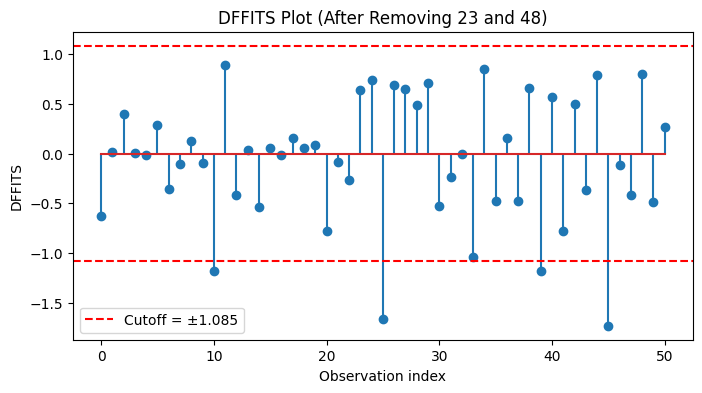

In [52]:
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(dffits_sens)), dffits_sens)
plt.axhline(dffits_cutoff_sens, color='red', linestyle='--')
plt.axhline(-dffits_cutoff_sens, color='red', linestyle='--', label=f"Cutoff = ±{dffits_cutoff_sens:.3f}")
plt.xlabel("Observation index")
plt.ylabel("DFFITS")
plt.title("DFFITS Plot (After Removing 23 and 48)")
plt.legend()
plt.show()

In [53]:
diag_sens = pd.DataFrame({
    "Index": model_data_clean2.index,
    "Fitted": fitted_vals_sens,
    "Residual": residuals_sens,
    "Studentized_Residual": studentized_residuals_sens,
    "Cooks_D": cooks_d_sens,
    "Leverage": leverage_sens,
    "DFFITS": dffits_sens
})

diag_sens["Flag_Cooks"] = diag_sens["Cooks_D"] > cooks_cutoff_sens
diag_sens["Flag_Leverage"] = diag_sens["Leverage"] > leverage_cutoff_sens
diag_sens["Flag_DFFITS"] = np.abs(diag_sens["DFFITS"]) > dffits_cutoff_sens

diag_sens["n_flags"] = (
    diag_sens["Flag_Cooks"].astype(int) +
    diag_sens["Flag_Leverage"].astype(int) +
    diag_sens["Flag_DFFITS"].astype(int)
)

flagged_sens = diag_sens[diag_sens["n_flags"] > 0].sort_values("n_flags", ascending=False)
print(flagged_sens)

    Index     Fitted   Residual  Studentized_Residual   Cooks_D  Leverage  \
10     10  30.728362  -5.940862             -1.206824  0.092730  0.491566   
27     27  56.650921 -10.911949             -2.096661  0.169542  0.387108   
41     41  63.376279 -11.482946             -1.996503  0.085981  0.259078   
47     47  37.668032  -8.094318             -1.704057  0.190346  0.508321   
14     14  66.752114   0.074553              0.021826  0.000106  0.764728   

      DFFITS  Flag_Cooks  Flag_Leverage  Flag_DFFITS  n_flags  
10 -1.186637        True          False         True        2  
27 -1.666297        True          False         True        2  
41 -1.180591        True          False         True        2  
47 -1.732657        True          False         True        2  
14  0.039351       False           True        False        1  


In [54]:
vif_sens = pd.DataFrame()
vif_sens["Variable"] = X_sens.columns
vif_sens["VIF"] = [
    variance_inflation_factor(X_sens.values, i)
    for i in range(X_sens.shape[1])
]

print(vif_sens.sort_values("VIF", ascending=False))

                                             Variable         VIF
0                                               const  141.981669
14                          Lutein + Zeaxanthin (mcg)    3.490866
11                    HEI 2015 Greens and Beans (0-5)    3.089631
3             Total Fruit Servings in cup equivalents    2.673823
4   Beta-Cryptoxanthin (provitamin A carotenoid) (...    2.524490
5                      HEI 2015 Refined Grains (0-10)    2.519889
13                                        Maltose (g)    2.438159
12  Seafood and Plant Protein Servings in ounce eq...    2.113441
2                               % Calories from SFA.x    2.074092
8      Alpha-Carotene (provitamin A carotenoid) (mcg)    1.970866
6                              3-Methylhistidine (mg)    1.773990
1                          student_low_income_percent    1.616977
9                        student_disabilities_percent    1.464934
7   Whole Grain Servings in ounce equivalents per ...    1.275909
10        

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [55]:
# Breusch-Pagan test
bp_test_sens = het_breuschpagan(residuals_sens, X_sens)
bp_results_sens = pd.DataFrame({
    "Statistic": ["LM Stat", "LM p-value", "F Stat", "F p-value"],
    "Value": bp_test_sens
})
print("\nBreusch-Pagan Test")
print(bp_results_sens)

# Durbin-Watson test
dw_sens = durbin_watson(residuals_sens)
print("\nDurbin-Watson:", dw_sens)


Breusch-Pagan Test
    Statistic      Value
0     LM Stat  14.133462
1  LM p-value   0.439816
2      F Stat   1.091125
3   F p-value   0.395945

Durbin-Watson: 2.7481758433048395


In [57]:
from scipy.stats import shapiro

# Get residuals from the final OLS model
residuals = ols_model_sens.resid

# Apply Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Test for Normality")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

# Interpretation
alpha = 0.05

if shapiro_p > alpha:
    print("Residuals appear approximately normal (fail to reject H0).")
else:
    print("Residuals do not appear normal (reject H0).")

Shapiro-Wilk Test for Normality
Test Statistic: 0.9874
P-value: 0.8625
Residuals appear approximately normal (fail to reject H0).
